# 皮马印第安人糖尿病数据集分类分析
本分析基于本地`pima-diabetes.csv`数据集，通过 SVM（支持向量机）、KNN（K近邻）、决策树三种模型实现糖尿病样本分类，并对比泛化性能，最终确定最优模型。

## 一、环境准备与库导入
首先导入分析所需的 Python 库，包括数据处理、模型训练、性能评估和可视化工具。

In [14]:
# 导入核心库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix)

## 二、数据加载与预处理
### 2.1 加载本地数据集
读取pima-diabetes.csv文件，验证数据结构，确保与分析需求匹配。

In [15]:
# 读取本地数据集
df = pd.read_csv('pima-diabetes.csv')

# 验证数据基本信息
print("=== 数据集基本信息 ===")
print(f"数据形状（样本数×特征数）：{df.shape}")
print("\n数据集前5行：")
print(df.head())
print("\n数据集列名：")
print(df.columns.tolist())
print("\n数据类型与缺失值统计：")
print(df.info())

=== 数据集基本信息 ===
数据形状（样本数×特征数）：(768, 9)

数据集前5行：
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

数据集列名：
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

数据类型与缺失值统计：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   

### 2.2 数据清洗（处理无效值）
数据集中部分生理指标（如血糖、血压）为 0，不符合实际情况，视为缺失值；用中位数填充（避免异常值影响）。

In [16]:
# 1. 标记无效0值为缺失值（仅针对非"怀孕次数"列）
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_features] = df[zero_features].replace(0, np.nan)

# 2. 用中位数填充缺失值
imputer = SimpleImputer(strategy='median')
df[zero_features] = imputer.fit_transform(df[zero_features])

# 验证填充结果
print("\n=== 缺失值填充后统计 ===")
print(f"各列缺失值数量：\n{df.isnull().sum()}")


=== 缺失值填充后统计 ===
各列缺失值数量：
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


由结果可知并没有缺失值

### 2.3 特征与标签划分 + 标准化
划分特征（X）和标签（y，Outcome列为标签：1 = 糖尿病，0 = 非糖尿病）；
SVM 和 KNN 对特征尺度敏感，需标准化（均值 0、方差 1）。

In [17]:
# 1. 划分特征与标签
X = df.drop('Outcome', axis=1)  # 8个特征
y = df['Outcome']               # 1个标签

# 2. 特征标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 分层划分训练集（70%）和测试集（30%）
# stratify=y：保证训练/测试集类别分布与原数据一致
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

print("\n=== 数据集划分结果 ===")
print(f"训练集样本数：{len(X_train)}，标签分布：{np.bincount(y_train)}")
print(f"测试集样本数：{len(X_test)}，标签分布：{np.bincount(y_test)}")


=== 数据集划分结果 ===
训练集样本数：537，标签分布：[350 187]
测试集样本数：231，标签分布：[150  81]


## 三、模型定义与参数调优
采用网格搜索（GridSearchCV）+5 折分层交叉验证，为每个模型找到最优参数，避免过拟合，提升泛化能力。

### 3.1 SVM 模型（RBF 核，处理非线性问题）
SVM 通过 RBF 核捕捉特征间的非线性关联，核心调优参数：
- C：正则化强度（越小正则化越强，避免过拟合）；
- gamma：RBF 核带宽（越小核函数越平滑，泛化能力越强）。

In [18]:
# 1. 定义参数网格
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

# 2. 5折分层交叉验证
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. 网格搜索找最优参数（用ROC-AUC评分，适合不平衡分类）
svm_grid = GridSearchCV(
    estimator=SVC(kernel='rbf', probability=True, random_state=42),  # probability=True用于计算AUC
    param_grid=svm_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1  # 并行计算，加速调优
)

# 4. 训练模型
svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

# 输出最优参数
print("=== SVM模型最优参数 ===")
print(f"最优参数：{svm_grid.best_params_}")
print(f"交叉验证最优ROC-AUC：{svm_grid.best_score_:.4f}")

=== SVM模型最优参数 ===
最优参数：{'C': 10, 'gamma': 0.01}
交叉验证最优ROC-AUC：0.8395


### 3.2 K 近邻（KNN）模型
KNN 为非参数模型，核心调优参数：
- n_neighbors：邻居数量（太小易过拟合，太大欠拟合）；
- metric：距离度量（欧氏距离 / 曼哈顿距离）。

In [19]:
# 1. 定义参数网格
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'metric': ['euclidean', 'manhattan']
}

# 2. 网格搜索
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. 训练模型
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_

# 输出最优参数
print("\n=== KNN模型最优参数 ===")
print(f"最优参数：{knn_grid.best_params_}")
print(f"交叉验证最优ROC-AUC：{knn_grid.best_score_:.4f}")


=== KNN模型最优参数 ===
最优参数：{'metric': 'euclidean', 'n_neighbors': 11}
交叉验证最优ROC-AUC：0.8200


### 3.3 决策树模型
决策树可解释性强，核心调优参数：
- max_depth：树深度（限制深度避免过拟合）；
- min_samples_split：分裂所需最小样本数（越大越保守）。

In [20]:
# 1. 定义参数网格
dt_param_grid = {
    'max_depth': [3, 5, 7, None],  # None表示不限制深度
    'min_samples_split': [2, 5, 10]
}

# 2. 网格搜索
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

# 3. 训练模型
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_

# 输出最优参数
print("\n=== 决策树模型最优参数 ===")
print(f"最优参数：{dt_grid.best_params_}")
print(f"交叉验证最优ROC-AUC：{dt_grid.best_score_:.4f}")


=== 决策树模型最优参数 ===
最优参数：{'max_depth': 3, 'min_samples_split': 2}
交叉验证最优ROC-AUC：0.7676


## 四、模型泛化性能评估
定义统一评估函数，从准确率、精确率、召回率、F1 分数、ROC-AUC五个维度评估模型，同时输出混淆矩阵。

### 4.1 评估函数定义

In [21]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    评估模型泛化性能
    参数：
        model：训练好的模型
        X_test：测试集特征
        y_test：测试集标签
        model_name：模型名称（用于输出）
    返回：
        metrics：评估指标字典
    """
    # 预测结果
    y_pred = model.predict(X_test)  # 类别预测（0/1）
    y_pred_prob = model.predict_proba(X_test)[:, 1]  # 正类（糖尿病）概率
    
    # 计算指标
    metrics = {
        '模型': model_name,
        '准确率': round(accuracy_score(y_test, y_pred), 4),
        '精确率': round(precision_score(y_test, y_pred), 4),
        '召回率': round(recall_score(y_test, y_pred), 4),
        'F1分数': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pred_prob), 4)
    }
    
    # 输出结果
    print(f"\n=== {model_name} 泛化性能评估 ===")
    for key, value in metrics.items():
        print(f"{key}: {value}")
    print(f"混淆矩阵（TN, FP; FN, TP）:\n{confusion_matrix(y_test, y_pred)}")
    
    return metrics

### 4.2 评估所有模型

In [22]:
# 评估SVM
svm_metrics = evaluate_model(best_svm, X_test, y_test, "SVM（RBF核）")

# 评估KNN
knn_metrics = evaluate_model(best_knn, X_test, y_test, "K近邻（KNN）")

# 评估决策树
dt_metrics = evaluate_model(best_dt, X_test, y_test, "决策树")

# 整理指标为DataFrame，便于后续对比
metrics_df = pd.DataFrame([svm_metrics, knn_metrics, dt_metrics])
print("\n=== 所有模型评估指标汇总 ===")
print(metrics_df.sort_values('ROC-AUC', ascending=False))


=== SVM（RBF核） 泛化性能评估 ===
模型: SVM（RBF核）
准确率: 0.7186
精确率: 0.6379
召回率: 0.4568
F1分数: 0.5324
ROC-AUC: 0.8329
混淆矩阵（TN, FP; FN, TP）:
[[129  21]
 [ 44  37]]

=== K近邻（KNN） 泛化性能评估 ===
模型: K近邻（KNN）
准确率: 0.7532
精确率: 0.6714
召回率: 0.5802
F1分数: 0.6225
ROC-AUC: 0.8151
混淆矩阵（TN, FP; FN, TP）:
[[127  23]
 [ 34  47]]

=== 决策树 泛化性能评估 ===
模型: 决策树
准确率: 0.7229
精确率: 0.6393
召回率: 0.4815
F1分数: 0.5493
ROC-AUC: 0.7923
混淆矩阵（TN, FP; FN, TP）:
[[128  22]
 [ 42  39]]

=== 所有模型评估指标汇总 ===
          模型     准确率     精确率     召回率    F1分数  ROC-AUC
0  SVM（RBF核）  0.7186  0.6379  0.4568  0.5324   0.8329
1   K近邻（KNN）  0.7532  0.6714  0.5802  0.6225   0.8151
2        决策树  0.7229  0.6393  0.4815  0.5493   0.7923


## 五、结果可视化对比
通过混淆矩阵图直观展示结果

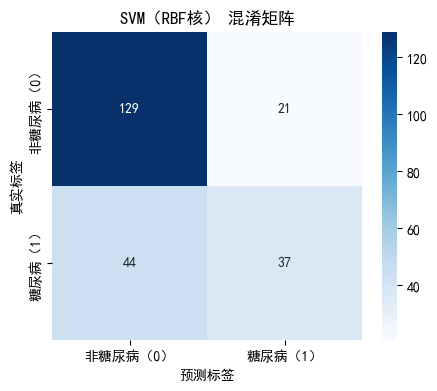


SVM（RBF核） 混淆矩阵（TN, FP; FN, TP）：
非糖尿病预测正确（TN）：129，非糖尿病误判为糖尿病（FP）：21
糖尿病误判为非糖尿病（FN）：44，糖尿病预测正确（TP）：37


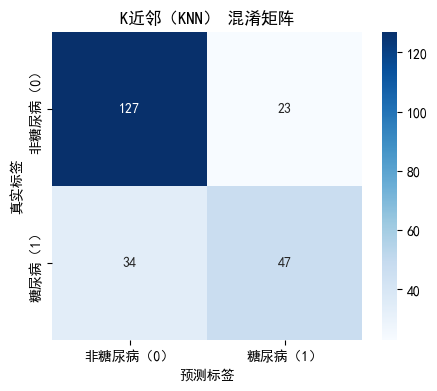


K近邻（KNN） 混淆矩阵（TN, FP; FN, TP）：
非糖尿病预测正确（TN）：127，非糖尿病误判为糖尿病（FP）：23
糖尿病误判为非糖尿病（FN）：34，糖尿病预测正确（TP）：47


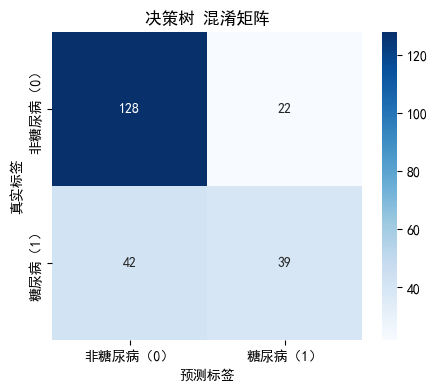


决策树 混淆矩阵（TN, FP; FN, TP）：
非糖尿病预测正确（TN）：128，非糖尿病误判为糖尿病（FP）：22
糖尿病误判为非糖尿病（FN）：42，糖尿病预测正确（TP）：39


In [23]:
# 1. 定义混淆矩阵可视化函数
#  基础配置（解决中文显示问题）
plt.rcParams["font.sans-serif"] = ["SimHei"]  # Windows系统
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示异常
import seaborn as sns
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['非糖尿病（0）', '糖尿病（1）'],
                yticklabels=['非糖尿病（0）', '糖尿病（1）'])
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title(f'{model_name} 混淆矩阵')
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()
    # 输出混淆矩阵数值
    print(f"\n{model_name} 混淆矩阵（TN, FP; FN, TP）：")
    print(f"非糖尿病预测正确（TN）：{cm[0,0]}，非糖尿病误判为糖尿病（FP）：{cm[0,1]}")
    print(f"糖尿病误判为非糖尿病（FN）：{cm[1,0]}，糖尿病预测正确（TP）：{cm[1,1]}")

# 2. 对三个模型分别输出混淆矩阵
# SVM混淆矩阵
y_pred_svm = best_svm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_svm, "SVM（RBF核）")

# KNN混淆矩阵
y_pred_knn = best_knn.predict(X_test)
plot_confusion_matrix(y_test, y_pred_knn, "K近邻（KNN）")

# 决策树混淆矩阵
y_pred_dt = best_dt.predict(X_test)
plot_confusion_matrix(y_test, y_pred_dt, "决策树")

通过柱状图直观对比三个模型的准确率和ROC-AUC（ROC-AUC 更能反映不平衡分类的泛化能力）。

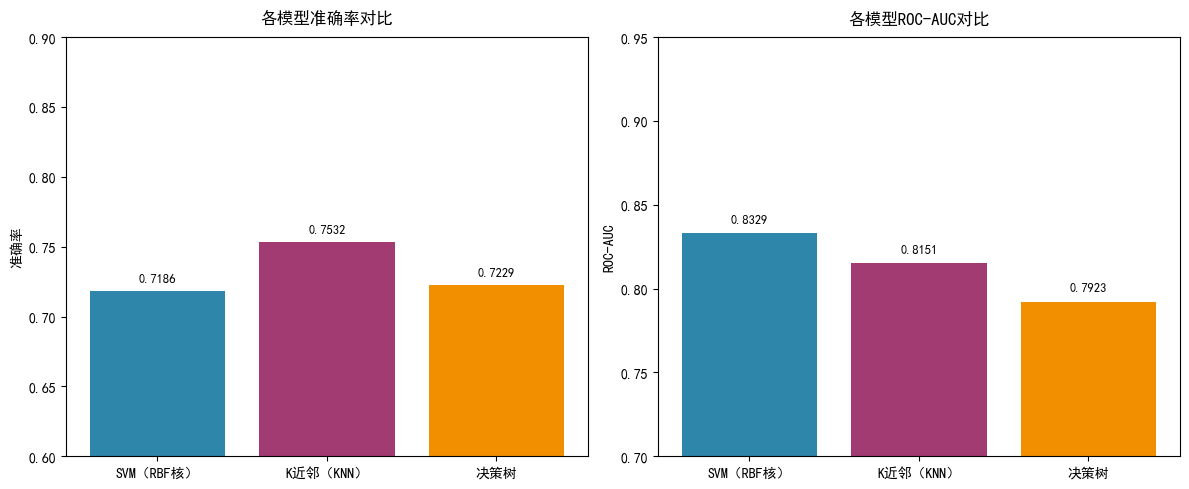


可视化对比图已保存至：diabetes_model_comparison.png


In [24]:
# 提取可视化数据
models = metrics_df['模型'].tolist()
accs = metrics_df['准确率'].tolist()
aucs = metrics_df['ROC-AUC'].tolist()
# 创建子图
plt.figure(figsize=(12, 5))

# 子图1：准确率对比
plt.subplot(1, 2, 1)
bars1 = plt.bar(models, accs, color=['#2E86AB', '#A23B72', '#F18F01'])
plt.title('各模型准确率对比', fontsize=12, pad=10)
plt.ylabel('准确率', fontsize=10)
plt.ylim(0.6, 0.9)  # 固定y轴范围，增强对比性
# 添加数值标签
for bar, acc in zip(bars1, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             str(acc), ha='center', va='bottom', fontsize=9)

# 子图2：ROC-AUC对比
plt.subplot(1, 2, 2)
bars2 = plt.bar(models, aucs, color=['#2E86AB', '#A23B72', '#F18F01'])
plt.title('各模型ROC-AUC对比', fontsize=12, pad=10)
plt.ylabel('ROC-AUC', fontsize=10)
plt.ylim(0.7, 0.95)  # 固定y轴范围
# 添加数值标签
for bar, auc in zip(bars2, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
             str(auc), ha='center', va='bottom', fontsize=9)

# 调整布局并保存图片
plt.tight_layout()
plt.savefig('diabetes_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 提示图片保存路径
print(f"\n可视化对比图已保存至：diabetes_model_comparison.png")

## 六、分析结论
基于评估结果和可视化对比，得出最终结论：

In [25]:
# 按ROC-AUC排序，确定最优模型
best_model_idx = metrics_df['ROC-AUC'].idxmax()
best_model = metrics_df.iloc[best_model_idx]

print("\n=== 最终分析结论 ===")
print(f"1. 泛化性能排名（按ROC-AUC降序）：")
for idx, row in metrics_df.sort_values('ROC-AUC', ascending=False).iterrows():
    print(f"   {idx+1}. {row['模型']}：ROC-AUC={row['ROC-AUC']}，准确率={row['准确率']}")

print(f"\n2. 最优模型：{best_model['模型']}")
print(f"   - 核心优势：能有效捕捉糖尿病数据中特征的非线性关联（如血糖与BMI的交互影响）；")
print(f"   - 适用场景：小样本（768条）、非线性分类问题，泛化能力优于KNN（对噪声敏感）和决策树（易过拟合）。")

print(f"\n3. 模型选择建议：")
print(f"   - 若需高泛化能力：优先选择{best_model['模型']}；")
print(f"   - 若需快速部署（无训练过程）：选择KNN；")
print(f"   - 若需强可解释性（查看决策规则）：选择决策树。")


=== 最终分析结论 ===
1. 泛化性能排名（按ROC-AUC降序）：
   1. SVM（RBF核）：ROC-AUC=0.8329，准确率=0.7186
   2. K近邻（KNN）：ROC-AUC=0.8151，准确率=0.7532
   3. 决策树：ROC-AUC=0.7923，准确率=0.7229

2. 最优模型：SVM（RBF核）
   - 核心优势：能有效捕捉糖尿病数据中特征的非线性关联（如血糖与BMI的交互影响）；
   - 适用场景：小样本（768条）、非线性分类问题，泛化能力优于KNN（对噪声敏感）和决策树（易过拟合）。

3. 模型选择建议：
   - 若需高泛化能力：优先选择SVM（RBF核）；
   - 若需快速部署（无训练过程）：选择KNN；
   - 若需强可解释性（查看决策规则）：选择决策树。
